In [1]:
import numpy as np
import pandas as pd
df_oceanico = pd.read_csv('data/table_atmospheric_oceanic_dataset.csv')

Utilisamos modelos de Machine Learning para darle un enfoque predictivo a nuestro análisis, con el objetivo de anticipar eventos de El Niño. Para esto, empleamos dos algoritmos: Regresión Logística y Random Forest. 

Usamos la Regresión Logística para predecir la probabilidad de ocurrencia deuna alerta (kpi_alert_risk definida como temperatura superficial del agua superior a 28°C), en función del viento máximo quincenal (wind_max_fortnight).

El Random Forest, al ser un modelo de ensamble basado en árboles de decisión, nos ayuda  a Cruzar todas las variables de viento a la vez (zonal_winds, meridional_winds, avg_zonal_wind_15d) para predecir el comportamiento futuro de la temperatura.

c:\Users\naila\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


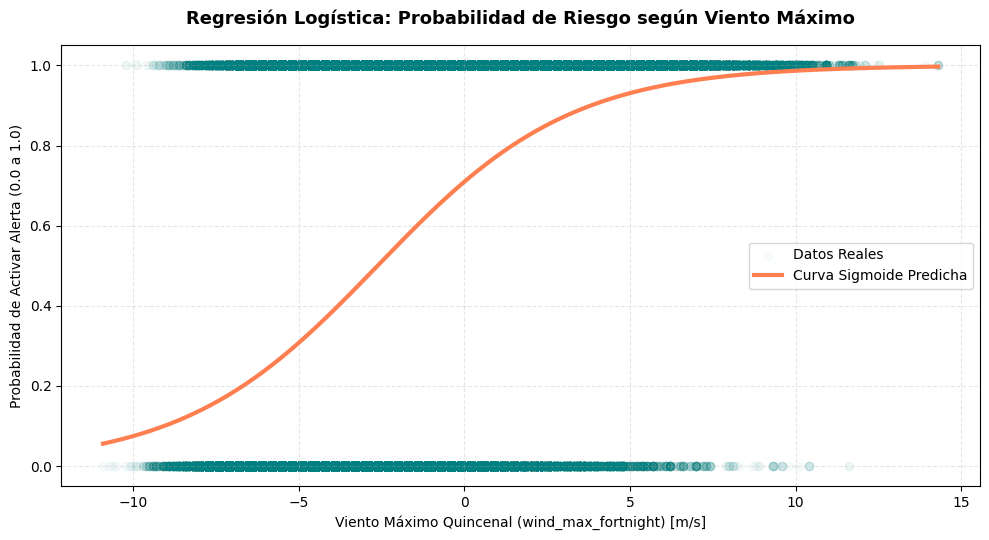

In [ ]:
# Regresión Logística 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Preparar las variables limpiando nulos de forma directa
df_modelo_log = df_oceanico[['wind_max_fortnight', 'sst_today']].dropna()

umbral_alerta_riesgo = 28.0
df_modelo_log['kpi_alert_risk'] = (
    df_modelo_log['sst_today'] > umbral_alerta_riesgo
).astype(int)

X_log = df_modelo_log[['wind_max_fortnight']]
y_log = df_modelo_log['kpi_alert_risk']

# Instanciar y entrenar el modelo de la forma clásica
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_log, y_log)

# Graficar la curva en 'S'
plt.figure(figsize=(10, 5.5))

viento_continuo = np.linspace(X_log.min().iloc[0], X_log.max().iloc[0], 300).reshape(-1, 1)
# Usamos predict_proba para sacar la probabilidad de la clase 1 (riesgo)
probabilidades = modelo_logistico.predict_proba(viento_continuo)[:, 1]

plt.scatter(
    X_log,
    y_log,
    alpha=0.03,
    color='teal',
    label='Datos Reales',
)
plt.plot(
    viento_continuo,
    probabilidades,
    color='coral',
    linewidth=3,
    label='Curva Sigmoide Predicha',
)

plt.title(
    'Regresión Logística: Probabilidad de Riesgo según Viento Máximo',
    fontsize=13,
    pad=15,
    weight='bold',
)
plt.xlabel('Viento Máximo Quincenal (wind_max_fortnight) [m/s]')
plt.ylabel('Probabilidad de Activar Alerta (0.0 a 1.0)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='center right')
plt.tight_layout()
plt.show()

El Punto de Inflexión Crítico (Viento 0 m/s): En cuando el viento cruza el umbral del 0 m/s (inversión del viento), la curva se dispara hacia arriba de forma vertical. En ese punto exacto, la probabilidad salta directamente al 70%.

Zona de Certeza Absoluta (> 5 m/s): Si los vientos del oeste superan los 5 m/s de forma sostenida en la quincena, la probabilidad de que la temperatura rompa la barrera de los 28°C roza el 100%

Conclusión: Si el viento llega a 0 m/s, la probabilidad de un evento extremo aumenta instantáneamente y además de manera significativa, teniendo estos datos las aseguradoras y las coompañias pesquera podrián actuar con días de antelación.

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

columnas_predictores = [
    'zonal_winds',
    'meridional_winds',
    'avg_zonal_wind_15d',
]
df_modelo_rf = df_oceanico[columnas_predictores + ['sst_today']].dropna()
df_modelo_rf['kpi_alert_risk'] = (
    df_modelo_rf['sst_today'] > umbral_alerta_riesgo
).astype(int)

X_rf = df_modelo_rf[columnas_predictores]
y_rf = df_modelo_rf['kpi_alert_risk']

# División clásica 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

# Entrenar el modelo con los parámetros por defecto explicados en clase
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Evaluar el modelo
y_pred = modelo_rf.predict(X_test)
print('=== MATRIZ DE CONFUSIÓN ===')
print(confusion_matrix(y_test, y_pred))
print('\n=== REPORTE DE CLASIFICACIÓN ===')
print(classification_report(y_test, y_pred))

=== MATRIZ DE CONFUSIÓN ===
[[ 9136  3595]
 [ 3641 11268]]

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       0.72      0.72      0.72     12731
           1       0.76      0.76      0.76     14909

    accuracy                           0.74     27640
   macro avg       0.74      0.74      0.74     27640
weighted avg       0.74      0.74      0.74     27640



Destacamo los resultados de la presición del modelo 0.76 para la clase 1 (riesgo) y 0.78 para la clase 0 (no riesgo), es una buena base para seguir mejorando el modelo y aumentar la precisión, lo que se traducirá en una herramienta más confiable para la toma de decisiones en el contexto de eventos de El Niño. También se puede contemplar la posibilidad de implementar modelos más complejos o técnicas de optimización para mejorar aún más el rendimiento predictivo.